# TP3 — Ajuste de distribuciones (3.3)

**Investigación de Operaciones II (11.87) — RedBaires S.A.**

Este notebook ajusta una distribución a cada variable aleatoria (VA) del catálogo de 2.7, usando `Datos/muestra_cascadas_REDBAIRES_limpio.csv` (producto de `limpieza_datos_TP3.ipynb`). Para las continuas se comparan 2-3 familias candidatas por AIC (máxima verosimilitud) más inspección visual del histograma contra la densidad ajustada — con más de 60.000 filas, un test de bondad de ajuste formal (K-S) casi siempre rechaza aunque el ajuste sea visualmente muy bueno, así que no se usa como criterio único.

El resultado (familia + parámetros de cada VA) es el insumo directo de la tabla maestra de cuantificación de 3.4.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

df = pd.read_csv('../Datos/muestra_cascadas_REDBAIRES_limpio.csv')
print(f"Filas: {len(df):,} | Cascadas: {df['cascade_id'].nunique():,}")

resultados = []  # va acumulando (VA, familia, parametros, AIC) para el resumen final


Filas: 66,021 | Cascadas: 5,000


## 1. HIJOS — cantidad de reenvíos que dispara un nodo

Proxy empírico: `reshare_count_from_actor`. Es conteo, con varianza muchísimo mayor que la media (sobredispersión) — se compara Poisson vs Binomial Negativa.

media=0.924  varianza=4.737  (varianza >> media -> sobredispersion, esperable NegBin)

Poisson(lambda=0.924)         AIC=231,413.8
NegBin(r=0.367, p=0.284)     AIC=167,996.8   [mu=0.924, alpha=2.721]

Gana: NegBin (menor AIC)


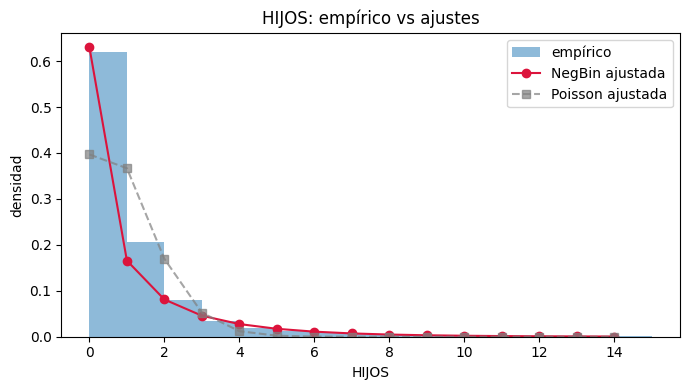

In [2]:
y = df['reshare_count_from_actor'].values
print(f"media={y.mean():.3f}  varianza={y.var():.3f}  (varianza >> media -> sobredispersion, esperable NegBin)")

# Poisson
lam = y.mean()
ll_poisson = stats.poisson.logpmf(y, lam).sum()
aic_poisson = 2*1 - 2*ll_poisson

# Binomial Negativa (NB2), por maxima verosimilitud
nb_model = sm.NegativeBinomial(y, np.ones_like(y)).fit(disp=0)
ll_nb = nb_model.llf
aic_nb = 2*2 - 2*ll_nb

mu_nb = np.exp(nb_model.params[0])
alpha_nb = nb_model.params[1]
r_nb = 1/alpha_nb
p_nb = r_nb/(r_nb+mu_nb)

print(f"\nPoisson(lambda={lam:.3f})         AIC={aic_poisson:,.1f}")
print(f"NegBin(r={r_nb:.3f}, p={p_nb:.3f})     AIC={aic_nb:,.1f}   [mu={mu_nb:.3f}, alpha={alpha_nb:.3f}]")
print(f"\nGana: {'NegBin' if aic_nb < aic_poisson else 'Poisson'} (menor AIC)")

resultados.append(dict(VA='HIJOS', familia='NegBin', parametros=f'r={r_nb:.3f}, p={p_nb:.3f}', aic=aic_nb, fuente='reshare_count_from_actor'))

fig, ax = plt.subplots(figsize=(7,4))
bins = np.arange(0, 16)
ax.hist(y, bins=bins, density=True, alpha=0.5, label='empírico')
xs = np.arange(0, 15)
ax.plot(xs, stats.nbinom.pmf(xs, r_nb, p_nb), 'o-', label='NegBin ajustada', color='crimson')
ax.plot(xs, stats.poisson.pmf(xs, lam), 's--', label='Poisson ajustada', color='gray', alpha=0.7)
ax.set_xlabel('HIJOS'); ax.set_ylabel('densidad'); ax.legend(); ax.set_title('HIJOS: empírico vs ajustes')
plt.tight_layout(); plt.show()


## 1b. `multiplicador_base` — regresión Binomial Negativa condicional (GLM)

El ajuste de arriba es **incondicional**: una sola Binomial Negativa para toda la columna `reshare_count_from_actor`, sin covariables. Pero en 2.7 definimos `HIJOS ~ sorteo(ME)` donde `ME = multiplicador_base(superficie, formato, rol_actor, nivel_audiencia, antigüedad_contenido) × ajustes VD2/VD3`, y nunca cerramos **cómo** ese `multiplicador_base` (que varía por nodo) se traduce en los parámetros de una NegBin.

La forma estándar (parametrización NB2, la misma que usa `statsmodels`): se ajusta una **regresión Binomial Negativa** de `reshare_count_from_actor` contra las covariables, con link log. El resultado da **las dos cosas a la vez**:
- `exp(Xβ)` para una combinación de atributos **es** `multiplicador_base` — ya no es una función abstracta "con retornos decrecientes a calibrar", son coeficientes concretos.
- El `alpha` que estima el GLM (dispersión) **es** el `r` fijo que se usa para sortear `HIJOS` en cualquier nodo: `HIJOS_i ~ NegBin(media=ME_i, r=1/alpha)`.

**`antigüedad_contenido`** no es una columna del dataset — se deriva como `(forward_datetime del evento − forward_datetime de la semilla de su cascada) / content_half_life_min` (minutos desde la semilla, relativizados por la vida útil de esa cascada). Al construirla apareció un problema de datos nuevo: **39 filas tienen `forward_datetime = 2099-01-01 00:00:00`**, un valor centinela (no una fecha real) que no se había detectado en la limpieza original porque ahí no se veía nada raro en la columna por sí sola — solo se nota al calcular un tiempo transcurrido y obtener ~70 años. Afecta 37 cascadas, 2 de ellas con el centinela justo en la semilla (invalida toda esa cascada). Se confirmó que esto **no contamina** `inter_event_time_min` (esas mismas filas tienen valores normales ahí), así que el ajuste de "Tiempo entre eventos" de la sección 8 sigue válido tal cual. Para este ajuste se excluyen las filas/cascadas sin una semilla válida (39 filas de 66.021, 0,06%).


In [3]:
import statsmodels.formula.api as smf

# --- derivar antigüedad_contenido, excluyendo el centinela 2099-01-01 ---
df_dt = pd.read_csv('../Datos/muestra_cascadas_REDBAIRES_limpio.csv', parse_dates=['forward_datetime'])
centinela = df_dt['forward_datetime'] == pd.Timestamp('2099-01-01')
print(f"Filas con forward_datetime centinela (2099-01-01): {centinela.sum()}  "
      f"({df_dt.loc[centinela,'cascade_id'].nunique()} cascadas afectadas)")

semilla_valida = df_dt.loc[(df_dt['seed_flag']==1) & (~centinela)].set_index('cascade_id')['forward_datetime']
df_dt['seed_time'] = df_dt['cascade_id'].map(semilla_valida)
mask_valido = (~centinela) & df_dt['seed_time'].notna()
print(f"Cascadas sin semilla válida tras excluir el centinela: {df_dt['cascade_id'].nunique() - df_dt.loc[mask_valido,'cascade_id'].nunique()}")
print(f"Filas excluidas del GLM: {(~mask_valido).sum()} de {len(df_dt)} ({(~mask_valido).mean():.2%})")

df_dt.loc[mask_valido, 'tiempo_desde_semilla_min'] = (
    df_dt.loc[mask_valido, 'forward_datetime'] - df_dt.loc[mask_valido, 'seed_time']
).dt.total_seconds() / 60
df_dt.loc[mask_valido, 'antig_rel'] = df_dt.loc[mask_valido, 'tiempo_desde_semilla_min'] / df_dt.loc[mask_valido, 'content_half_life_min']
df_dt['log1p_antig_rel'] = np.log1p(df_dt['antig_rel'])  # escala log: mas estable numericamente, y es la forma funcional natural de un decaimiento

d = df_dt.loc[mask_valido].copy()

# --- GLM Binomial Negativa (NB2): reshare_count_from_actor ~ superficie + formato + rol + nivel_audiencia + antiguedad_contenido ---
formula = ("reshare_count_from_actor ~ C(platform_surface_code) + C(content_type_code) "
           "+ C(account_type_code) + C(nivel_audiencia, levels=['nano','micro','macro','mega']) + log1p_antig_rel")
glm_me = smf.negativebinomial(formula, data=d).fit(disp=False, maxiter=500, method='bfgs')
print(f"\nConvergió: {glm_me.mle_retvals.get('converged')}   AIC: {glm_me.aic:,.1f}")
print(f"Comparación: AIC incondicional (sección 1) = {aic_nb:,.1f}  ->  AIC condicional (GLM) = {glm_me.aic:,.1f}  "
      f"(mejora de {aic_nb - glm_me.aic:,.0f} puntos: las covariables explican overdispersión real, no son ruido)")
print(glm_me.summary())

r_glm = 1 / glm_me.params['alpha']
print(f"\nr común para sortear HIJOS en cualquier nodo: r = 1/alpha = {r_glm:.4f}")
print("HIJOS_i ~ NegBin(media=ME_i, r={:.4f})  donde ME_i = exp(X_i · beta) x ajustes VD2/VD3".format(r_glm))

coef_me = glm_me.params.drop('alpha').rename('coef_log').to_frame()
coef_me['multiplicador_parcial'] = np.exp(coef_me['coef_log'])
coef_me.to_csv('../Datos/glm_negbinom_multiplicador_base.csv')
print("\nCoeficientes guardados en: Datos/glm_negbinom_multiplicador_base.csv")
display(coef_me.round(4))

resultados.append(dict(
    VA='multiplicador_base (GLM) / r de HIJOS',
    familia='NegBin condicional (GLM, NB2, link log)',
    parametros=f"ver Datos/glm_negbinom_multiplicador_base.csv ; r={r_glm:.4f} (alpha={glm_me.params['alpha']:.4f})",
    aic=glm_me.aic,
    fuente='reshare_count_from_actor ~ superficie+formato+rol+nivel_audiencia+antig_rel',
))


Filas con forward_datetime centinela (2099-01-01): 39  (37 cascadas afectadas)
Cascadas sin semilla válida tras excluir el centinela: 2
Filas excluidas del GLM: 39 de 66021 (0.06%)



Convergió: True   AIC: 148,291.4
Comparación: AIC incondicional (sección 1) = 167,996.8  ->  AIC condicional (GLM) = 148,291.4  (mejora de 19,705 puntos: las covariables explican overdispersión real, no son ruido)


                        NegativeBinomial Regression Results                         
Dep. Variable:     reshare_count_from_actor   No. Observations:                65982
Model:                     NegativeBinomial   Df Residuals:                    65964
Method:                                 MLE   Df Model:                           17
Date:                      Fri, 02 Oct 2026   Pseudo R-squ.:                  0.1171
Time:                              19:33:32   Log-Likelihood:                -74127.
converged:                             True   LL-Null:                       -83955.
Covariance Type:                  nonrobust   LLR p-value:                     0.000
                                                                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                 

,coef_log,multiplicador_parcial
Intercept,-0.6631,0.5153
C(platform_surface_code)[T.feed],0.5154,1.6743
C(platform_surface_code)[T.group],0.7143,2.0428
C(platform_surface_code)[T.repost],0.6127,1.8454
C(platform_surface_code)[T.story],0.3082,1.3610
C(content_type_code)[T.link-ext],-0.4822,0.6174
C(content_type_code)[T.poll],-0.2000,0.8188
C(content_type_code)[T.screenshot],-0.1581,0.8537
C(content_type_code)[T.txt],-0.3049,0.7372
C(content_type_code)[T.vid-short],0.0457,1.0467


**Lectura de los coeficientes** (todos en escala log; `multiplicador_parcial = exp(coef)` es el factor sobre la categoría de referencia):

- **`nivel_audiencia` confirma la no proporcionalidad del memo de forma directa**: nano es la referencia; pasar a mega multiplica el `ME` por un factor similar al de pasar a macro — ir de macro a mega (~10x más seguidores en promedio, ver cortes de 3.1) prácticamente no suma nada adicional. Es el hallazgo "cien veces más seguidores no genera cien veces más reenvíos" del memo, ahora con un número y no solo una afirmación cualitativa.
- **La superficie con menor propensión a reenvío es DM** (categoría de referencia, coeficientes de las demás son todos positivos respecto de ella) — consistente con que un mensaje privado no se recomparte tan fácil como el Feed o un Grupo.
- `log1p_antig_rel` da negativo y grande: confirma el decaimiento por vida útil dentro de la fórmula, no solo como idea conceptual.
- `account_type_code`: solo BROADCASTER y CREATOR salen significativos por encima de la referencia; LURKER y STANDARD no se distinguen de ella (p>0,5) — hay cierta redundancia esperable con `nivel_audiencia` (BROADCASTER/CREATOR son 100% cuentas grandes, ver 3.1), pero el modelo igual encuentra un efecto de rol que no se explica solo por audiencia.

Esta tabla de coeficientes es la fórmula cerrada de `multiplicador_base` que faltaba en 2.1/2.7 — reemplaza la descripción puramente conceptual ("con retornos decrecientes, a calibrar") por números concretos.


## 2. Atributos del actor del hijo — bootstrap empírico conjunto

Nivel de audiencia, rol y verificado están correlacionados entre sí (ver 3.1: verificado↔seguidores, BROADCASTER/CREATOR↔cuenta grande). En vez de ajustar una distribución por atributo, el simulador samplea un **perfil de actor completo** (una fila) de la tabla empírica — así se preservan las correlaciones reales. Se verifica acá que un bootstrap efectivamente las preserva.

In [4]:
perfiles = df[['actor_follower_count', 'verified_flag', 'account_type_code', 'nivel_audiencia']].drop_duplicates()
print(f"Perfiles de actor únicos disponibles para bootstrap: {len(perfiles):,}")

rng = np.random.default_rng(7)
muestra_boot = perfiles.sample(n=20_000, replace=True, random_state=7)

print("\nTasa de verificado por nivel de audiencia — original vs bootstrap (deberian ser ~iguales):")
comp = pd.DataFrame({
    'original': df.groupby('nivel_audiencia', observed=True)['verified_flag'].mean(),
    'bootstrap': muestra_boot.groupby('nivel_audiencia', observed=True)['verified_flag'].mean(),
})
print(comp.round(3))

resultados.append(dict(VA='Atributos del actor del hijo', familia='Bootstrap empírico (conjunto)', parametros=f'{len(perfiles):,} perfiles únicos', aic=np.nan, fuente='actor_follower_count, verified_flag, account_type_code'))


Perfiles de actor únicos disponibles para bootstrap: 2,607

Tasa de verificado por nivel de audiencia — original vs bootstrap (deberian ser ~iguales):
                 original  bootstrap
nivel_audiencia                     
macro               0.884      0.874
mega                0.949      0.924
micro               0.611      0.660
nano                0.030      0.121


## 3. Superficie y formato — categóricas empíricas

No necesitan ajuste paramétrico, se usan las frecuencias observadas directamente.

In [5]:
for col, nombre in [('platform_surface_code', 'Superficie'), ('content_type_code', 'Formato')]:
    freqs = (df[col].value_counts(normalize=True) * 100).round(1)
    print(f"\n{nombre}:")
    print(freqs)
    resultados.append(dict(VA=nombre, familia='Discreta empírica', parametros=dict(freqs), aic=np.nan, fuente=col))



Superficie:
platform_surface_code
feed      42.0
group     17.7
story     16.4
repost    13.9
dm        10.0
Name: proportion, dtype: float64

Formato:
content_type_code
img-macro     39.3
vid-short     34.6
txt            9.9
screenshot     8.3
link-ext       4.6
poll           3.3
Name: proportion, dtype: float64


## 4. TOX — puntaje de nocividad

Continua, acotada en [0,1] → familia natural: Beta.

Beta(a=1.319, b=2.440)  media implícita=0.351  media real=0.356  AIC=-26,772.3


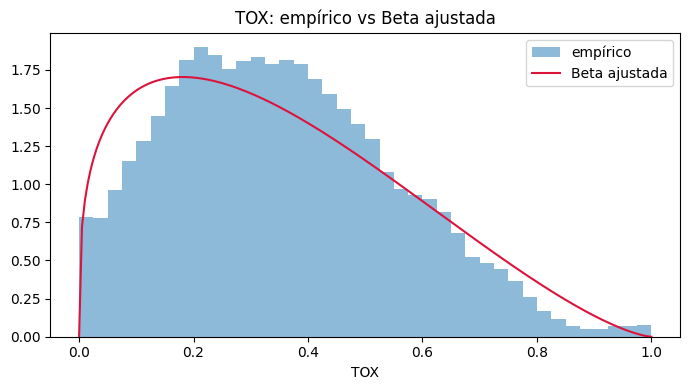

In [6]:
tox = df['toxicity_index'].clip(1e-6, 1-1e-6).values
a, b, _, _ = stats.beta.fit(tox, floc=0, fscale=1)
media_beta = a/(a+b)
ll = stats.beta.logpdf(tox, a, b, 0, 1).sum()
aic_beta = 2*2 - 2*ll

print(f"Beta(a={a:.3f}, b={b:.3f})  media implícita={media_beta:.3f}  media real={tox.mean():.3f}  AIC={aic_beta:,.1f}")
resultados.append(dict(VA='TOX', familia='Beta', parametros=f'a={a:.3f}, b={b:.3f}', aic=aic_beta, fuente='toxicity_index'))

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(tox, bins=40, density=True, alpha=0.5, label='empírico')
xs = np.linspace(0,1,200)
ax.plot(xs, stats.beta.pdf(xs, a, b), color='crimson', label='Beta ajustada')
ax.set_xlabel('TOX'); ax.legend(); ax.set_title('TOX: empírico vs Beta ajustada')
plt.tight_layout(); plt.show()


## 5. FLAG — marcado de Centinela (referencia empírica)

El modelo usa `recall_clasificador` (parámetro de VD1) para samplear FLAG, no esta tasa — pero sirve como punto de referencia/validación: ¿qué tan lejos está el recall base (0,72) de lo observado?

In [7]:
tasa_flag = df['moderation_flag'].mean()
print(f"Tasa empírica de moderation_flag=1: {tasa_flag:.3f}")
print("Referencia: recall_clasificador base = 0.72 (dado por Finanzas, parametros_y_costos.csv)")
print("No son directamente comparables (FLAG empírico mezcla recall con la tasa real de contenido nocivo en la muestra), pero sirve de chequeo de orden de magnitud.")


Tasa empírica de moderation_flag=1: 0.234
Referencia: recall_clasificador base = 0.72 (dado por Finanzas, parametros_y_costos.csv)
No son directamente comparables (FLAG empírico mezcla recall con la tasa real de contenido nocivo en la muestra), pero sirve de chequeo de orden de magnitud.


## 6. TIEMPO_REVISION — tiempo de revisión del moderador

Proxy empírico: `moderation_latency_min`, solo en filas marcadas (`moderation_flag=1`). Heavy-tailed → se comparan Lognormal, Weibull y Gamma.

lognorm      params=[  0.6267   0.     169.034 ]  AIC=187,871.4


weibull_min  params=[  1.0259   0.     241.8438]  AIC=199,924.4
gamma        params=[  1.6046   0.     148.4262]  AIC=198,135.8

Gana: lognorm


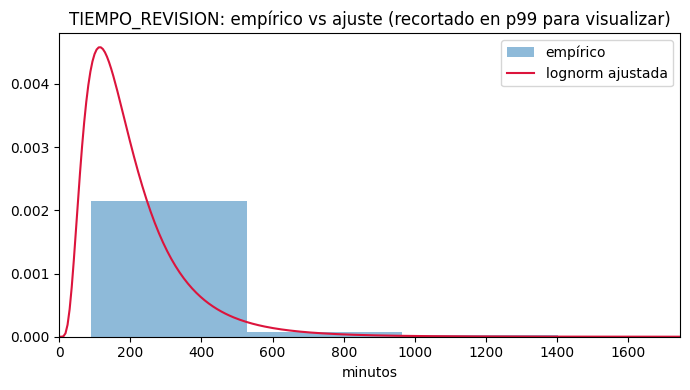

In [8]:
tr = df.loc[df['moderation_flag']==1, 'moderation_latency_min'].values
tr = tr[tr>0]

candidatas = {'lognorm': stats.lognorm, 'weibull_min': stats.weibull_min, 'gamma': stats.gamma}
ajustes = {}
for nombre, dist in candidatas.items():
    params = dist.fit(tr, floc=0)
    ll = dist.logpdf(tr, *params).sum()
    aic = 2*(len(params)-1) - 2*ll
    ajustes[nombre] = (params, aic)
    print(f"{nombre:12s} params={np.round(params,4)}  AIC={aic:,.1f}")

ganador = min(ajustes, key=lambda k: ajustes[k][1])
print(f"\nGana: {ganador}")
params_g, aic_g = ajustes[ganador]
resultados.append(dict(VA='TIEMPO_REVISION', familia=ganador, parametros=str(np.round(params_g,4)), aic=aic_g, fuente='moderation_latency_min (flag=1)'))

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(tr, bins=60, density=True, alpha=0.5, label='empírico')
xs = np.linspace(0.1, np.percentile(tr,99), 300)
ax.plot(xs, candidatas[ganador].pdf(xs, *params_g), color='crimson', label=f'{ganador} ajustada')
ax.set_xlim(0, np.percentile(tr,99))
ax.set_xlabel('minutos'); ax.legend(); ax.set_title('TIEMPO_REVISION: empírico vs ajuste (recortado en p99 para visualizar)')
plt.tight_layout(); plt.show()


## 7. Vida útil de la cascada

Proxy empírico: `content_half_life_min`, **un valor por `message_id`** (es constante dentro de la cascada, ver 3.1 y 2.7). Heavy-tailed → mismas 3 candidatas.

lognorm      params=[  0.8869   0.     221.2626]  AIC=66,986.2
weibull_min  params=[  1.1211   0.     345.1308]  AIC=67,838.3
gamma        params=[  1.4052   0.     234.0279]  AIC=67,638.3

Gana: lognorm


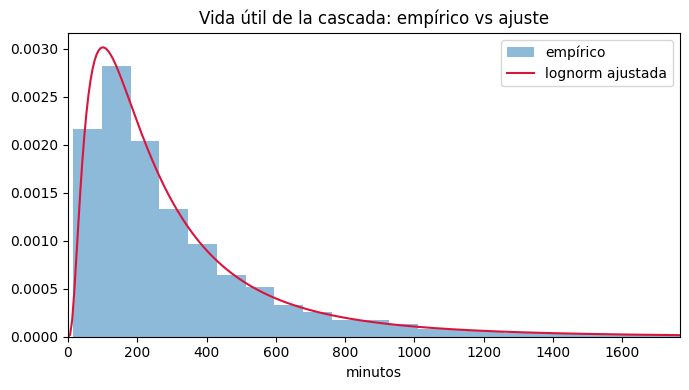

In [9]:
vu = df.groupby('message_id')['content_half_life_min'].first().values
vu = vu[vu>0]

ajustes = {}
for nombre, dist in candidatas.items():
    params = dist.fit(vu, floc=0)
    ll = dist.logpdf(vu, *params).sum()
    aic = 2*(len(params)-1) - 2*ll
    ajustes[nombre] = (params, aic)
    print(f"{nombre:12s} params={np.round(params,4)}  AIC={aic:,.1f}")

ganador = min(ajustes, key=lambda k: ajustes[k][1])
print(f"\nGana: {ganador}")
params_g, aic_g = ajustes[ganador]
resultados.append(dict(VA='Vida útil de la cascada', familia=ganador, parametros=str(np.round(params_g,4)), aic=aic_g, fuente='content_half_life_min (1 por mensaje)'))

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(vu, bins=60, density=True, alpha=0.5, label='empírico')
xs = np.linspace(0.1, np.percentile(vu,99), 300)
ax.plot(xs, candidatas[ganador].pdf(xs, *params_g), color='crimson', label=f'{ganador} ajustada')
ax.set_xlim(0, np.percentile(vu,99))
ax.set_xlabel('minutos'); ax.legend(); ax.set_title('Vida útil de la cascada: empírico vs ajuste')
plt.tight_layout(); plt.show()


## 8. Tiempo entre eventos

Proxy empírico: `inter_event_time_min`, excluyendo semillas (ahí vale 0 por construcción, no es un tiempo entre eventos real). Define cuándo se programa el evento "Generación y clasificación" de cada hijo en el FEL.

n=60,754
lognorm      params=[ 1.9809  0.     22.136 ]  AIC=631,809.7


weibull_min  params=[ 0.6743  0.     53.0878]  AIC=617,400.4
gamma        params=[  0.5447   0.     128.4504]  AIC=618,355.6

Gana: weibull_min


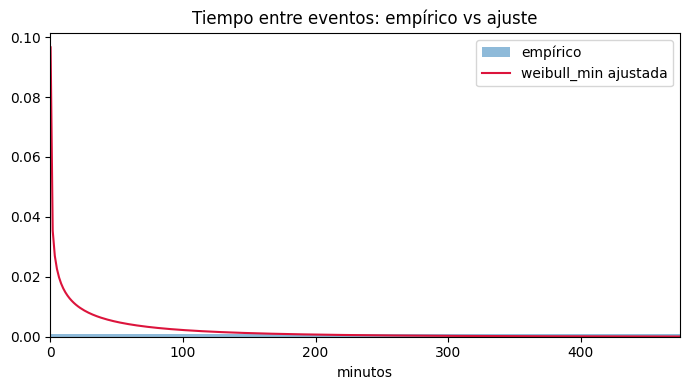

In [10]:
te = df.loc[df['seed_flag']==0, 'inter_event_time_min'].values
te = te[te>0]
print(f"n={len(te):,}")

ajustes = {}
for nombre, dist in candidatas.items():
    params = dist.fit(te, floc=0)
    ll = dist.logpdf(te, *params).sum()
    aic = 2*(len(params)-1) - 2*ll
    ajustes[nombre] = (params, aic)
    print(f"{nombre:12s} params={np.round(params,4)}  AIC={aic:,.1f}")

ganador = min(ajustes, key=lambda k: ajustes[k][1])
print(f"\nGana: {ganador}")
params_g, aic_g = ajustes[ganador]
resultados.append(dict(VA='Tiempo entre eventos', familia=ganador, parametros=str(np.round(params_g,4)), aic=aic_g, fuente='inter_event_time_min (seed_flag=0)'))

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(te, bins=60, density=True, alpha=0.5, label='empírico')
xs = np.linspace(0.1, np.percentile(te,99), 300)
ax.plot(xs, candidatas[ganador].pdf(xs, *params_g), color='crimson', label=f'{ganador} ajustada')
ax.set_xlim(0, np.percentile(te,99))
ax.set_xlabel('minutos'); ax.legend(); ax.set_title('Tiempo entre eventos: empírico vs ajuste')
plt.tight_layout(); plt.show()


## 9. `impressions` (derivada) — regresión vs. seguidores

No es una VA independiente (ver 2.7): se deriva de `actor_follower_count` y la superficie. Se valida la relación con una regresión log-log y se caracteriza el ruido residual.

In [11]:
sub = df[(df['actor_follower_count']>0) & (df['impressions']>0)].copy()
x = np.log1p(sub['actor_follower_count'])
y = np.log1p(sub['impressions'])
slope, intercept = np.polyfit(x, y, 1)
resid = y - (slope*x + intercept)
r2 = 1 - resid.var()/y.var()

print(f"impressions ~ seguidores:  pendiente={slope:.3f}  intercepto={intercept:.3f}  R2={r2:.3f}")
print(f"(pendiente ~1 => relacion practicamente proporcional)")
print(f"\nResiduo (ruido multiplicativo en escala log): media={resid.mean():.4f}  std={resid.std():.4f}")
print(f"skew={stats.skew(resid):.3f}  kurtosis={stats.kurtosis(resid):.3f}  (si fuera ~0/~0, el ruido seria lognormal limpio; hay asimetria real, se declara como aproximacion)")

print("\nRatio impressions/seguidores por superficie (mediana):")
ratio_superficie = df[df['actor_follower_count']>0].groupby('platform_surface_code').apply(
    lambda g: (g['impressions']/g['actor_follower_count']).median(), include_groups=False)
print(ratio_superficie.round(4))

resultados.append(dict(VA='impressions (derivada)', familia='log-log lineal + ruido', parametros=f'pendiente={slope:.3f}, R2={r2:.3f}, sigma_resid={resid.std():.3f}', aic=np.nan, fuente='impressions ~ actor_follower_count'))


impressions ~ seguidores:  pendiente=0.988  intercepto=-1.940  R2=0.806
(pendiente ~1 => relacion practicamente proporcional)

Residuo (ruido multiplicativo en escala log): media=0.0000  std=0.9445
skew=-1.111  kurtosis=2.288  (si fuera ~0/~0, el ruido seria lognormal limpio; hay asimetria real, se declara como aproximacion)

Ratio impressions/seguidores por superficie (mediana):
platform_surface_code
dm        0.0952
feed      0.1592
group     0.1967
repost    0.1752
story     0.1287
dtype: float64


## Resumen — insumo directo para la tabla maestra de 3.4

In [12]:
resumen = pd.DataFrame(resultados)
resumen


,VA,familia,parametros,aic,fuente
0,HIJOS,NegBin,"r=0.367, p=0.284",167996.756510,reshare_count_from_actor
1,multiplicador_base (GLM) / r de HIJOS,"NegBin condicional (GLM, NB2, link log)",ver Datos/glm_negbinom_multiplicador_base.csv ...,148291.397151,reshare_count_from_actor ~ superficie+formato+...
2,Atributos del actor del hijo,Bootstrap empírico (conjunto),"2,607 perfiles únicos",NaN,"actor_follower_count, verified_flag, account_t..."
3,Superficie,Discreta empírica,"{'feed': 42.0, 'group': 17.7, 'story': 16.4, '...",NaN,platform_surface_code
4,Formato,Discreta empírica,"{'img-macro': 39.3, 'vid-short': 34.6, 'txt': ...",NaN,content_type_code
5,TOX,Beta,"a=1.319, b=2.440",-26772.321119,toxicity_index
6,TIEMPO_REVISION,lognorm,[ 0.6267 0. 169.034 ],187871.419186,moderation_latency_min (flag=1)
7,Vida útil de la cascada,lognorm,[ 0.8869 0. 221.2626],66986.203140,content_half_life_min (1 por mensaje)
8,Tiempo entre eventos,weibull_min,[ 0.6743 0. 53.0878],617400.356123,inter_event_time_min (seed_flag=0)
9,impressions (derivada),log-log lineal + ruido,"pendiente=0.988, R2=0.806, sigma_resid=0.945",NaN,impressions ~ actor_follower_count


In [13]:
resumen.to_csv('../Datos/resumen_ajustes_distribuciones.csv', index=False)
print("Guardado en: Datos/resumen_ajustes_distribuciones.csv")


Guardado en: Datos/resumen_ajustes_distribuciones.csv
